# V2 — 탐색 차트와 서킷 이동 영상

위에서 아래로 모든 셀을 실행하세요. 두 언어는 같은 원본 자료를 사용합니다. V2는 탐색용이며 최종 비교 랩 선정은 남아 있습니다. 패키지 설치 방법은 README.ko.md에 있습니다.

In [1]:
from pathlib import Path
# 프로젝트 루트 또는 언어별 노트북 폴더에서 프로젝트 위치를 찾습니다.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'docs/analysis_design.json').exists()
             and (p / 'data/raw').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the baku-2026 project')


## 원본과 시간 검증

In [2]:
"""V2: 탐색용 비교 차트와 같은 시각에 맞춘 서킷 이동 영상을 만듭니다.

원본 로딩 → 시간·위치 검증 → PNG/MP4/GIF 저장 순서로 읽으시면 됩니다.
전체 깃발 시간 구간을 반영한 최종 페이스 분석은 아직 완료되지 않았습니다.
"""
"""Build reproducible descriptive F1 visuals from saved OpenF1 responses."""
from pathlib import Path
import json, sys, subprocess, zipfile
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image, ImageDraw, ImageFont

# ROOT was located in the setup cell.
RAW = ROOT/'data/raw'
LANGUAGE = 'ko'
OUT = ROOT/'outputs'/LANGUAGE
WORK = ROOT/'work'/LANGUAGE
WORK.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True,exist_ok=True)
import imageio_ffmpeg

BG='#101721'; PANEL='#172230'; FG='#f2f5f8'; MUTED='#aab8c8'; GRID='#304052'
RUS='#00d7b6'; VER='#679cff'; YELLOW='#f0c65d'; SOFT='#ff6d79'
available_fonts = {item.name for item in font_manager.fontManager.ttflist}
FONT_FAMILY = next((name for name in ['Apple SD Gothic Neo', 'AppleGothic', 'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans CJK JP'] if name in available_fonts), None)
if FONT_FAMILY is None:
    raise RuntimeError('Install a Korean font; see README.ko.md')
plt.rcParams.update({'font.family':FONT_FAMILY,'axes.unicode_minus':False,'font.size':13,'text.color':FG,
 'axes.labelcolor':MUTED,'xtick.color':MUTED,'ytick.color':MUTED,'axes.edgecolor':GRID,
 'axes.facecolor':BG,'figure.facecolor':BG,'savefig.facecolor':BG})
# 저장된 원본을 표로 읽습니다. 이 단계에는 네트워크가 필요 없습니다.
def read(name): return pd.DataFrame(json.loads((RAW/name).read_text()))
def dt(x): return pd.to_datetime(x,format='ISO8601',utc=True)
def secs(x): return dt(x).astype('int64')/1e9
def scalar(x): return pd.Timestamp(x).timestamp()
def axstyle(ax):
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y',color=GRID,alpha=.5,zorder=0)
    ax.tick_params(length=0,pad=8)
def canvas(num,title,subtitle):
    fig=plt.figure(figsize=(12,10),dpi=150)
    fig.text(.065,.955,f'바쿠 2026  /  러셀 vs 베르스타펜',fontsize=11,color=RUS,weight='bold')
    fig.text(.935,.955,f'0{num} / 03',ha='right',fontsize=11,color=MUTED)
    fig.text(.065,.904,title,fontsize=28,weight='bold')
    fig.text(.065,.863,subtitle,fontsize=12.5,color=MUTED)
    return fig
def footer(fig,method):
    fig.text(.065,.049,method,fontsize=9,color=MUTED,linespacing=1.5)
    fig.text(.065,.021,'출처: OpenF1 · 세션 11377 · 2026-09-26 | 독립적인 기술통계 분석',fontsize=9,color=MUTED)

laps=read('laps_session_key-11377.json')
drivers=read('drivers_session_key-11377.json').set_index('driver_number')
pair=laps[laps.driver_number.isin([63,3])].copy()
pair['t']=secs(pair.date_start)
assert len(pair)==102 and not pair.duplicated(['driver_number','lap_number']).any()
assert not pair[['date_start','lap_duration']].isna().any().any()
assert pair.lap_duration.gt(0).all()
rus=pair[pair.driver_number==63].sort_values('lap_number')
ver=pair[pair.driver_number==3].sort_values('lap_number')
position=read('position_session_key-11377_driver_number-63.json')
assert position.position.eq(1).all(), 'gap_to_leader is not always gap to Russell'
intervals=read('intervals_session_key-11377_driver_number-3.json')
intervals['t']=secs(intervals.date)
intervals=intervals.sort_values('t')
intervals['gap']=pd.to_numeric(intervals.gap_to_leader,errors='coerce')
gap_missing=int(intervals.gap.isna().sum())
results=read('session_result_session_key-11377.json').set_index('driver_number')
assert results.loc[3,'gap_to_leader']==0.196 and results.loc[63,'position']==1
assert abs(intervals.iloc[-1].gap-.196)<1e-9
rc=read('race_control_session_key-11377.json');rc['t']=secs(rc.date)
stints=read('stints_session_key-11377.json')
pit=read('pit_session_key-11377.json');pit['t']=secs(pit.date)
start_t=rus.t.to_numpy(); lap_n=rus.lap_number.to_numpy()
end_t=rus.iloc[-1].t+rus.iloc[-1].lap_duration
map_t=np.r_[start_t,end_t]; map_l=np.r_[lap_n,52]
# 시간 표본을 선두의 랩 진행에 맞춰 x축에 표시합니다.
def race_lap(t): return np.interp(t,map_t,map_l)
# 미래 표본은 사용하지 않고 12초보다 오래된 과거 표본도 표시하지 않습니다.
def gap_at(t):
    j=np.searchsorted(intervals.t.to_numpy(),t,side='right')-1
    if j<0 or t-intervals.iloc[j].t>12:return None
    return float(intervals.iloc[j].gap) if pd.notna(intervals.iloc[j].gap) else None

# 다음 선두 랩 시작은 경계 후보이며 실제 세이프티카 철수 시각이 아닙니다.
sc_starts=rc[rc.message.eq('SAFETY CAR DEPLOYED')].t.to_list()
sc_in=rc[rc.message.eq('SAFETY CAR IN THIS LAP')]
sc_ends=[float(rus[rus.lap_number==int(r.lap_number)+1].iloc[0].t) for r in sc_in.itertuples()]
assert len(sc_starts)==len(sc_ends)==2
gap_pre=gap_at(float(rus[rus.lap_number==31].iloc[0].t))



## 공식 시간 차이와 SC 경계 후보

In [3]:
# 02: 좌표의 거리가 아닌 공식 시간 차이 표본으로 격차를 그립니다.
fig=canvas(2,'접전의 결승선, 달라진 경기 흐름','최종 격차만으로는 경기 중 두 드라이버의 시간 차이를 알 수 없습니다.')
for x,value,label,col in [(.065,f'{gap_pre:.3f}s','31랩 시작 직전의 시간 차이 표본',VER),(.375,'2','세이프티카 투입 횟수',YELLOW),(.69,'0.196s','공식 최종 격차',RUS)]:
    fig.text(x,.775,value,fontsize=34,weight='bold',color=col)
    fig.text(x,.740,label,fontsize=9.5,color=MUTED)
ax=fig.add_axes([.09,.285,.84,.375]);axstyle(ax)
x=race_lap(intervals.t)
ax.plot(x,intervals.gap,color=VER,lw=2.1)
for k,(a,b) in enumerate(zip(sc_starts,sc_ends),1):
    ax.axvspan(race_lap(a),race_lap(b),color=YELLOW,alpha=.15)
    ax.text((race_lap(a)+race_lap(b))/2,19.5,f'SC{k}',ha='center',color=YELLOW,fontsize=10)
ax.set(xlim=(1,52),ylim=(0,21),ylabel='베르스타펜과 러셀의 시간 차이 (초)',xlabel='선두 차량의 랩 진행 (근사값)')
ax.set_xticks([1,10,20,30,40,51]);ax.set_yticks([0,5,10,15,20])
ax.scatter([31],[gap_pre],s=45,color=VER,zorder=6)
ax.annotate('두 차량 모두 31랩 피트레인 진입\n타이어 구간 기록: 미디엄 → 소프트',xy=(31,17.2),xytext=(16,18.5),fontsize=10,color=FG,arrowprops={'arrowstyle':'-','color':MUTED})
ax.annotate('36랩: 전 차량 피트레인 통과 지시',xy=(36.7,2),xytext=(32,7),fontsize=9.5,color=FG,arrowprops={'arrowstyle':'-','color':MUTED})
ax.scatter([52],[.196],s=40,color=RUS,zorder=6,clip_on=False)
fig.text(.065,.176,'해석 범위',fontsize=10,weight='bold',color=RUS)
fig.text(.065,.157,'피트 활동이 겹친 세이프티카 구간에서 시간 차이가 줄었습니다.\n이 차트만으로 타이어 교체의 독립적 효과를 분리할 수 없습니다.',fontsize=14,linespacing=1.45,va='top')
footer(fig,'시간 차이: 원본 gap_to_leader 사용. 결측 표본 2개는 채우지 않았습니다.\nSC 음영의 끝은 복귀 예고 다음 선두 랩의 시작으로, 실제 철수 시각 확정값이 아닙니다.')
fig.savefig(OUT/'02_gap_timeline.png');plt.close(fig)



## 탐색용 페이스와 타이어 맥락

In [4]:
# 03: 같은 랩끼리 비교합니다. 고정 창과 공지 랩 필터는 탐색용이며 최종 필터가 아닙니다.
# 랩별 차이를 먼저 계산한 후 중앙값을 구합니다. 두 중앙값의 차이가 아닙니다.
piv=pair.pivot(index='lap_number',columns='driver_number',values='lap_duration')
flags=set(rc.loc[rc.flag.isin(['YELLOW','DOUBLE YELLOW','RED']),'lap_number'].dropna().astype(int))
pit_laps=set(pit[pit.driver_number.isin([63,3])].lap_number.astype(int))
out_laps=set(pair[pair.is_pit_out_lap.eq(True)].lap_number.astype(int))
windows=[]
for a,b,label in [(21,30,'첫 세이프티카 이전'),(41,50,'두 번째 세이프티카 이후')]:
    chosen=[n for n in range(a,b+1) if n not in flags|pit_laps|out_laps]
    d=(piv.loc[chosen,3]-piv.loc[chosen,63])
    windows.append({'a':a,'b':b,'label':label,'laps':chosen,'delta':d,'median':float(d.median())})
assert len(windows[0]['laps'])==9 and len(windows[1]['laps'])==9
fig=canvas(3,'같은 랩 비교에 경기 맥락을 더하기','동일 랩 차이 = 베르스타펜 랩타임 - 러셀 랩타임')
for k,w in enumerate(windows):
    xx=.065+.47*k
    fig.text(xx,.805,w['label'],fontsize=10,color=MUTED,weight='bold')
    fig.text(xx,.753,f"{w['median']:+.3f}초 / 랩",fontsize=26,color=RUS,weight='bold')
    fig.text(xx,.717,f"동일 랩 차이의 중앙값 · {len(w['laps'])}개 랩",fontsize=11,color=MUTED)
    ax=fig.add_axes([.095+.47*k,.452,.365,.21]);axstyle(ax)
    dd=w['delta'];ax.axhline(0,color=MUTED,lw=1)
    for n,val in dd.items():
        color=RUS if val>=0 else VER
        ax.vlines(n,0,val,color=color,lw=2);ax.scatter([n],[val],color=color,s=42,zorder=4)
    ax.axhline(w['median'],color=FG,ls=':',lw=1)
    ax.set(xlim=(w['a']-.7,w['b']-.3),ylim=(-.25,.7),xlabel='경기 랩')
    ax.set_xticks(w['laps'][::2]);ax.set_yticks([-.2,0,.2,.4,.6])
    if k==0:ax.set_ylabel('랩타임 차이 (초)')
fig.text(.065,.381,'양수 = 러셀이 빠름  •  음수 = 베르스타펜이 빠름',fontsize=11,color=MUTED)
ax=fig.add_axes([.12,.232,.80,.10]);ax.set_facecolor(BG)
for y,d in [(1,63),(0,3)]:
    for s in stints[stints.driver_number==d].itertuples():
        col=YELLOW if s.compound=='MEDIUM' else SOFT
        ax.broken_barh([(s.lap_start-.5,s.lap_end-s.lap_start+1)],(y-.24,.48),facecolors=col,edgecolors=BG,linewidth=2)
        if s.lap_end-s.lap_start>=8:
            ax.text((s.lap_start+s.lap_end)/2,y,f'{"미디엄" if s.compound == "MEDIUM" else "소프트"} · 시작 {s.tyre_age_at_start}랩 사용',ha='center',va='center',color=BG,fontsize=10,weight='bold')
        else:
            ax.text((s.lap_start+s.lap_end)/2,y,f'S · {s.tyre_age_at_start}',ha='center',va='center',color=BG,fontsize=9,weight='bold')
ax.set(xlim=(.5,51.5),ylim=(-.5,1.5));ax.set_yticks([0,1],['VER','RUS']);ax.set_xticks([1,10,20,31,36,51]);ax.tick_params(length=0,labelsize=10)
ax.spines[:].set_visible(False)
fig.text(.065,.177,'후반 표본에서 동일 랩의 페이스 차이가 작았습니다.',fontsize=15,weight='bold')
fig.text(.065,.148,'타이어 사용량·연료·교통 차이는 남아 있습니다. 마모 효과나 인과 분석은 아닙니다.\n타이어 구간: OpenF1 stints. 사용량은 구간 시작 시점의 랩 수입니다.',fontsize=11.5,color=MUTED,linespacing=1.45,va='top')
footer(fig,'탐색용: 21–30 / 41–50랩 창에서 공지 랩 30 / 50을 제외, 각각 9개 랩 비교.\n각 랩과 깃발 시간 구간의 겹침 검토가 남아 있어 최종 비교 랩이 아닙니다.')
fig.savefig(OUT/'03_paired_pace_and_tyres.png');plt.close(fig)



## 위치 표본 동기화와 영상 인코딩

In [5]:
# 01: 두 차량 위치 표본을 같은 시각에 맞춰 보간하여 영상을 만듭니다.
locations={}; qc={}
for d in [63,3]:
    f=next(RAW.glob(f'location_session_key-11377_driver_number-{d}_*.json'))
    z=read(f.name);z['t']=secs(z.date);z=z.sort_values('t')
    assert not z.t.duplicated().any() and not z[['x','y']].isna().any().any()
    assert z.t.diff().max()<=2
    locations[d]=z
    qc[str(d)]={'rows':len(z),'max_gap_seconds':float(z.t.diff().max()),'duplicate_times':int(z.t.duplicated().sum())}
W,H=1280,1066
fig=plt.figure(figsize=(W/100,H/100),dpi=100)
fig.text(.055,.952,'바쿠 2026  /  러셀 vs 베르스타펜',fontsize=11,color=RUS,weight='bold')
fig.text(.945,.952,'01 / 03',ha='right',fontsize=11,color=MUTED)
fig.text(.055,.900,'첫 세이프티카 구간의 차량 이동',fontsize=29,weight='bold')
fig.text(.055,.860,'두 차량의 위치 표본을 같은 경기 시각에 맞춰 재생합니다.',fontsize=13,color=MUTED)
ax=fig.add_axes([.06,.285,.88,.40]);ax.axis('off');ax.set_aspect('equal')
z=locations[63]; t29=float(rus[rus.lap_number==29].iloc[0].t);t30=float(rus[rus.lap_number==30].iloc[0].t)
track=z[(z.t>=t29)&(z.t<t30)]
track_x=np.r_[track.x,track.x.iloc[0]];track_y=np.r_[track.y,track.y.iloc[0]]
ax.plot(track_x,track_y,color=GRID,lw=12,solid_capstyle='round')
ax.plot(track_x,track_y,color='#637487',lw=2,solid_capstyle='round')
ax.set_xlim(z.x.min()-1000,z.x.max()+1000);ax.set_ylim(z.y.min()-1000,z.y.max()+1000)
fig.text(.055,.238,'RUS  ·  조지 러셀',color=RUS,fontsize=13,weight='bold')
fig.text(.505,.238,'VER  ·  막스 베르스타펜',color=VER,fontsize=13,weight='bold')
fig.text(.055,.184,'표시 구간: 29랩 ~ 33랩 시작 · 18배속',fontsize=13,weight='bold')
fig.text(.055,.157,'두 차량 모두 31랩에 피트레인 진입 기록이 있으며 세이프티카가 투입된 상태입니다.\n위치 표본은 대략적인 이동을 보여주며 정확한 주행 라인은 아닙니다.',fontsize=11,color=MUTED,linespacing=1.6,va='top')
fig.text(.055,.079,'서킷 윤곽: 러셀 29랩 위치 궤적 · 짧은 표본 사이를 선형 보간\n시간 차이: 최신 과거 공식 표본 사용. 지도상 두 점의 거리를 뜻하지 않습니다.',fontsize=10,color=MUTED,linespacing=1.55)
fig.text(.055,.030,'출처: OpenF1 · 세션 11377 · 2026-09-26 | 중계 영상 미사용',fontsize=10,color=MUTED)
fig.canvas.draw(); base=Image.fromarray(np.asarray(fig.canvas.buffer_rgba()).copy()).convert('RGB')
trans=ax.transData
font_path=font_manager.findfont(FONT_FAMILY)
bold_path=font_manager.findfont(font_manager.FontProperties(family=FONT_FAMILY,weight='bold'))
font=lambda n,b=False:ImageFont.truetype(bold_path if b else font_path,n)
t0=max(locations[63].t.min(),locations[3].t.min(),t29)
t1=min(locations[63].t.max(),locations[3].t.max())
fps=20;speed=18;nframes=int(np.ceil((t1-t0)/speed*fps))+1
ffmpeg=imageio_ffmpeg.get_ffmpeg_exe()
proc=subprocess.Popen([ffmpeg,'-y','-loglevel','error','-f','rawvideo','-vcodec','rawvideo','-pix_fmt','rgb24','-s',f'{W}x{H}','-r',str(fps),'-i','-','-an','-c:v','libx264','-preset','fast','-crf','20','-pix_fmt','yuv420p','-movflags','+faststart',str(OUT/'01_track_replay.mp4')],stdin=subprocess.PIPE)
snapshots=[]
# 선형 보간으로 같은 시각에 맞춥니다. 실제 주행 라인을 복원할 수는 없습니다.
for k,t in enumerate(np.linspace(t0,t1,nframes)):
    img=base.copy();draw=ImageDraw.Draw(img)
    lap=int(np.floor(race_lap(t)))
    clock=pd.Timestamp(t,unit='s',tz='UTC').strftime('%H:%M:%S')
    gap=gap_at(t)
    draw.text((70,180),f'선두 랩 {lap:02d}   |   {clock} UTC',font=font(19,True),fill=FG)
    draw.text((70,223),f'VER와 RUS의 차이  {gap:.3f}s' if gap is not None else '사용 가능한 시간 차이 표본 없음',font=font(32,True),fill=VER)
    active=sc_starts[0]<=t<sc_ends[0]
    badge='세이프티카' if active else '세이프티카 이전'
    draw.rounded_rectangle((895,181,1210,231),radius=9,fill=YELLOW if active else GRID)
    draw.text((912,193),badge,font=font(19,True),fill=BG if active else FG)
    pix={}
    for d,col in [(63,RUS),(3,VER)]:
        zz=locations[d]
        px,py=trans.transform((np.interp(t,zz.t,zz.x),np.interp(t,zz.t,zz.y)));py=H-py
        pix[d]=(px,py)
        draw.ellipse((px-10,py-10,px+10,py+10),fill=col,outline=FG,width=2)
        tx=min(W-80,max(40,px+16));ty=py-24 if d==63 else py+13
        draw.rounded_rectangle((tx-4,ty-2,tx+50,ty+25),radius=4,fill=BG)
        draw.text((tx,ty),'RUS' if d==63 else 'VER',font=font(17,True),fill=col)
    draw.rectangle((70,753,1210,758),fill=GRID)
    draw.rectangle((70,753,70+1140*k/(nframes-1),758),fill=RUS)
    proc.stdin.write(img.tobytes())
    if k in [0,nframes//2,nframes-1]:
        img.save(WORK/f'video_frame_{k}.png');snapshots.append(img.copy())
    if k%200==0: print('video frame',k,'/',nframes,flush=True)
proc.stdin.close(); assert proc.wait()==0



video frame 0 / 605


video frame 200 / 605


video frame 400 / 605


video frame 600 / 605


## GIF·포스터·검증 기록 저장

In [6]:
# MP4와 함께 브라우저에서 반복 재생할 GIF와 포스터를 생성합니다.
subprocess.run([ffmpeg,'-y','-v','error','-i',str(OUT/'01_track_replay.mp4'),'-vf','fps=10,scale=900:-1:flags=lanczos,split[s0][s1];[s0]palettegen=max_colors=128[p];[s1][p]paletteuse=dither=bayer:bayer_scale=3','-loop','0',str(OUT/'01_track_replay.gif')],check=True)
subprocess.run([ffmpeg,'-y','-v','error','-i',str(OUT/'01_track_replay.mp4'),'-frames:v','1',str(OUT/'01_track_replay_poster.png')],check=True)
plt.close(fig)
sheet=Image.new('RGB',(W*3,H))
for k,img in enumerate(snapshots):sheet.paste(img,(k*W,0))
sheet.resize((1920,533)).save(WORK/'video_contact_sheet.png')

metrics={'session_key':11377,'drivers':{str(d):drivers.loc[d,'full_name'] for d in [63,3]},
 'analysis_status':'EXPLORATORY_TEMPORAL_ELIGIBILITY_PENDING',
 'lap_rows':len(pair),'unique_driver_lap_keys':len(pair.drop_duplicates(['driver_number','lap_number'])),
 'gap_at_leader_lap31_latest_sample_s':gap_pre,'official_finish_gap_s':.196,
 'safety_car_count':2,'unfilled_gap_samples':gap_missing,'location_qc':qc,
 'windows':[{'start':w['a'],'end':w['b'],'retained_laps':w['laps'],'median_VER_minus_RUS_s':w['median']} for w in windows],
 'video':{'start_utc':pd.Timestamp(t0,unit='s',tz='UTC').isoformat(),'end_utc':pd.Timestamp(t1,unit='s',tz='UTC').isoformat(),'fps':fps,'speed':speed,'frames':nframes}}
(OUT/'validation.json').write_text(json.dumps(metrics,indent=2))
pair.to_csv(ROOT/'data/processed/paired_laps.csv',index=False)
print(json.dumps(metrics,indent=2),flush=True)


# 언어별 미리보기 템플릿을 결과 폴더에 복사해 브라우저에서 재생합니다.
(OUT/'preview.html').write_text((ROOT/'docs/preview.ko.html').read_text(encoding='utf-8'), encoding='utf-8')


{
  "session_key": 11377,
  "drivers": {
    "63": "George RUSSELL",
    "3": "Max VERSTAPPEN"
  },
  "analysis_status": "EXPLORATORY_TEMPORAL_ELIGIBILITY_PENDING",
  "lap_rows": 102,
  "unique_driver_lap_keys": 102,
  "gap_at_leader_lap31_latest_sample_s": 12.763,
  "official_finish_gap_s": 0.196,
  "safety_car_count": 2,
  "unfilled_gap_samples": 2,
  "location_qc": {
    "63": {
      "rows": 2115,
      "max_gap_seconds": 1.0,
      "duplicate_times": 0
    },
    "3": {
      "rows": 2115,
      "max_gap_seconds": 1.0,
      "duplicate_times": 0
    }
  },
  "windows": [
    {
      "start": 21,
      "end": 30,
      "retained_laps": [
        21,
        22,
        23,
        24,
        25,
        26,
        27,
        28,
        29
      ],
      "median_VER_minus_RUS_s": 0.3160000000000025
    },
    {
      "start": 41,
      "end": 50,
      "retained_laps": [
        41,
        42,
        43,
        44,
        45,
        46,
        47,
        48,
        49
  

1696

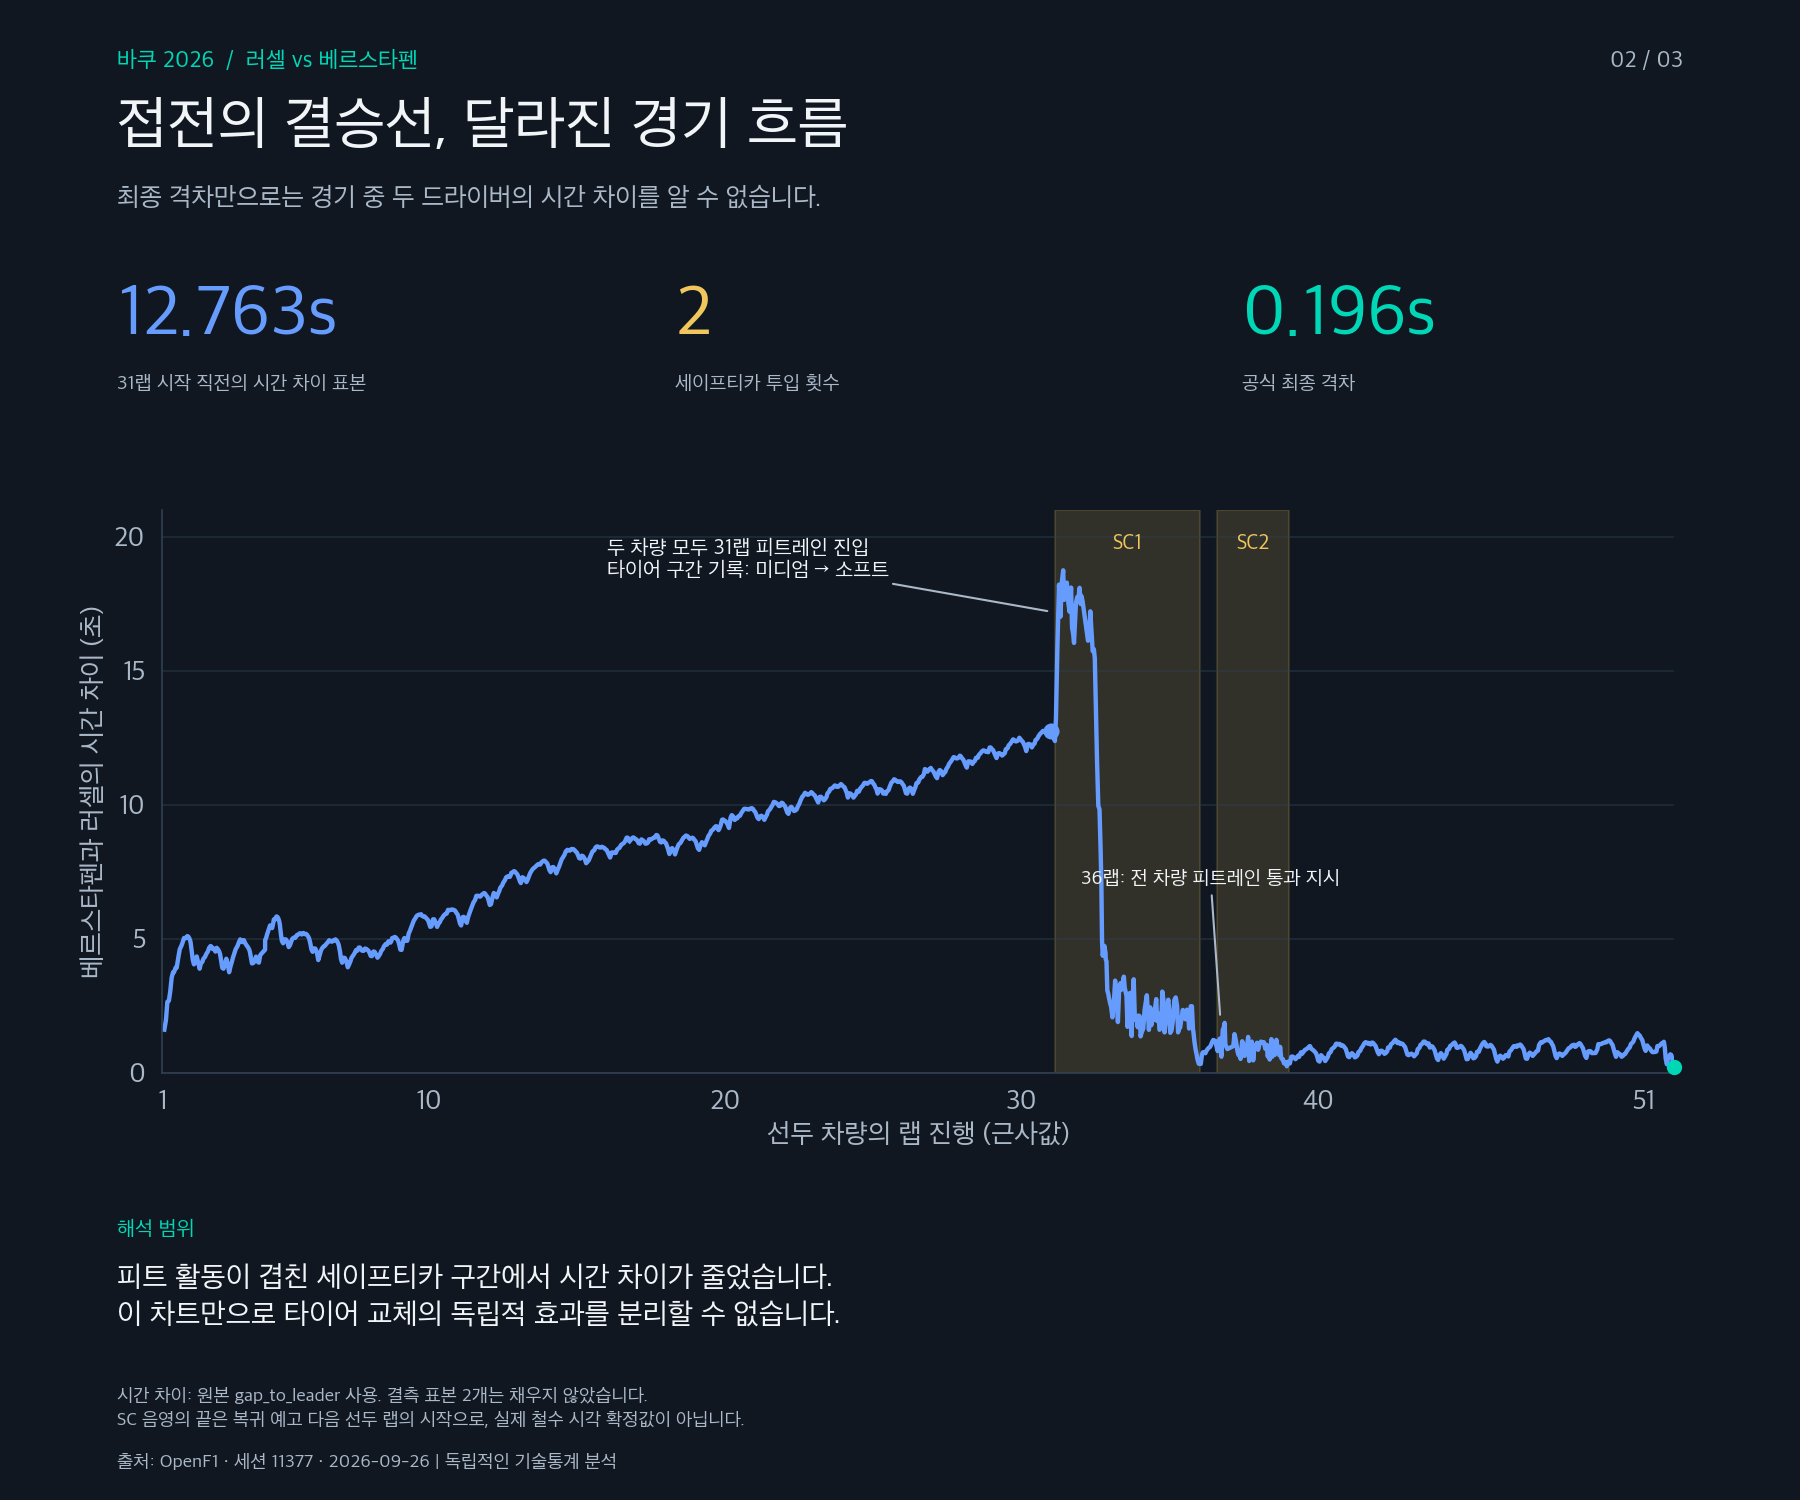

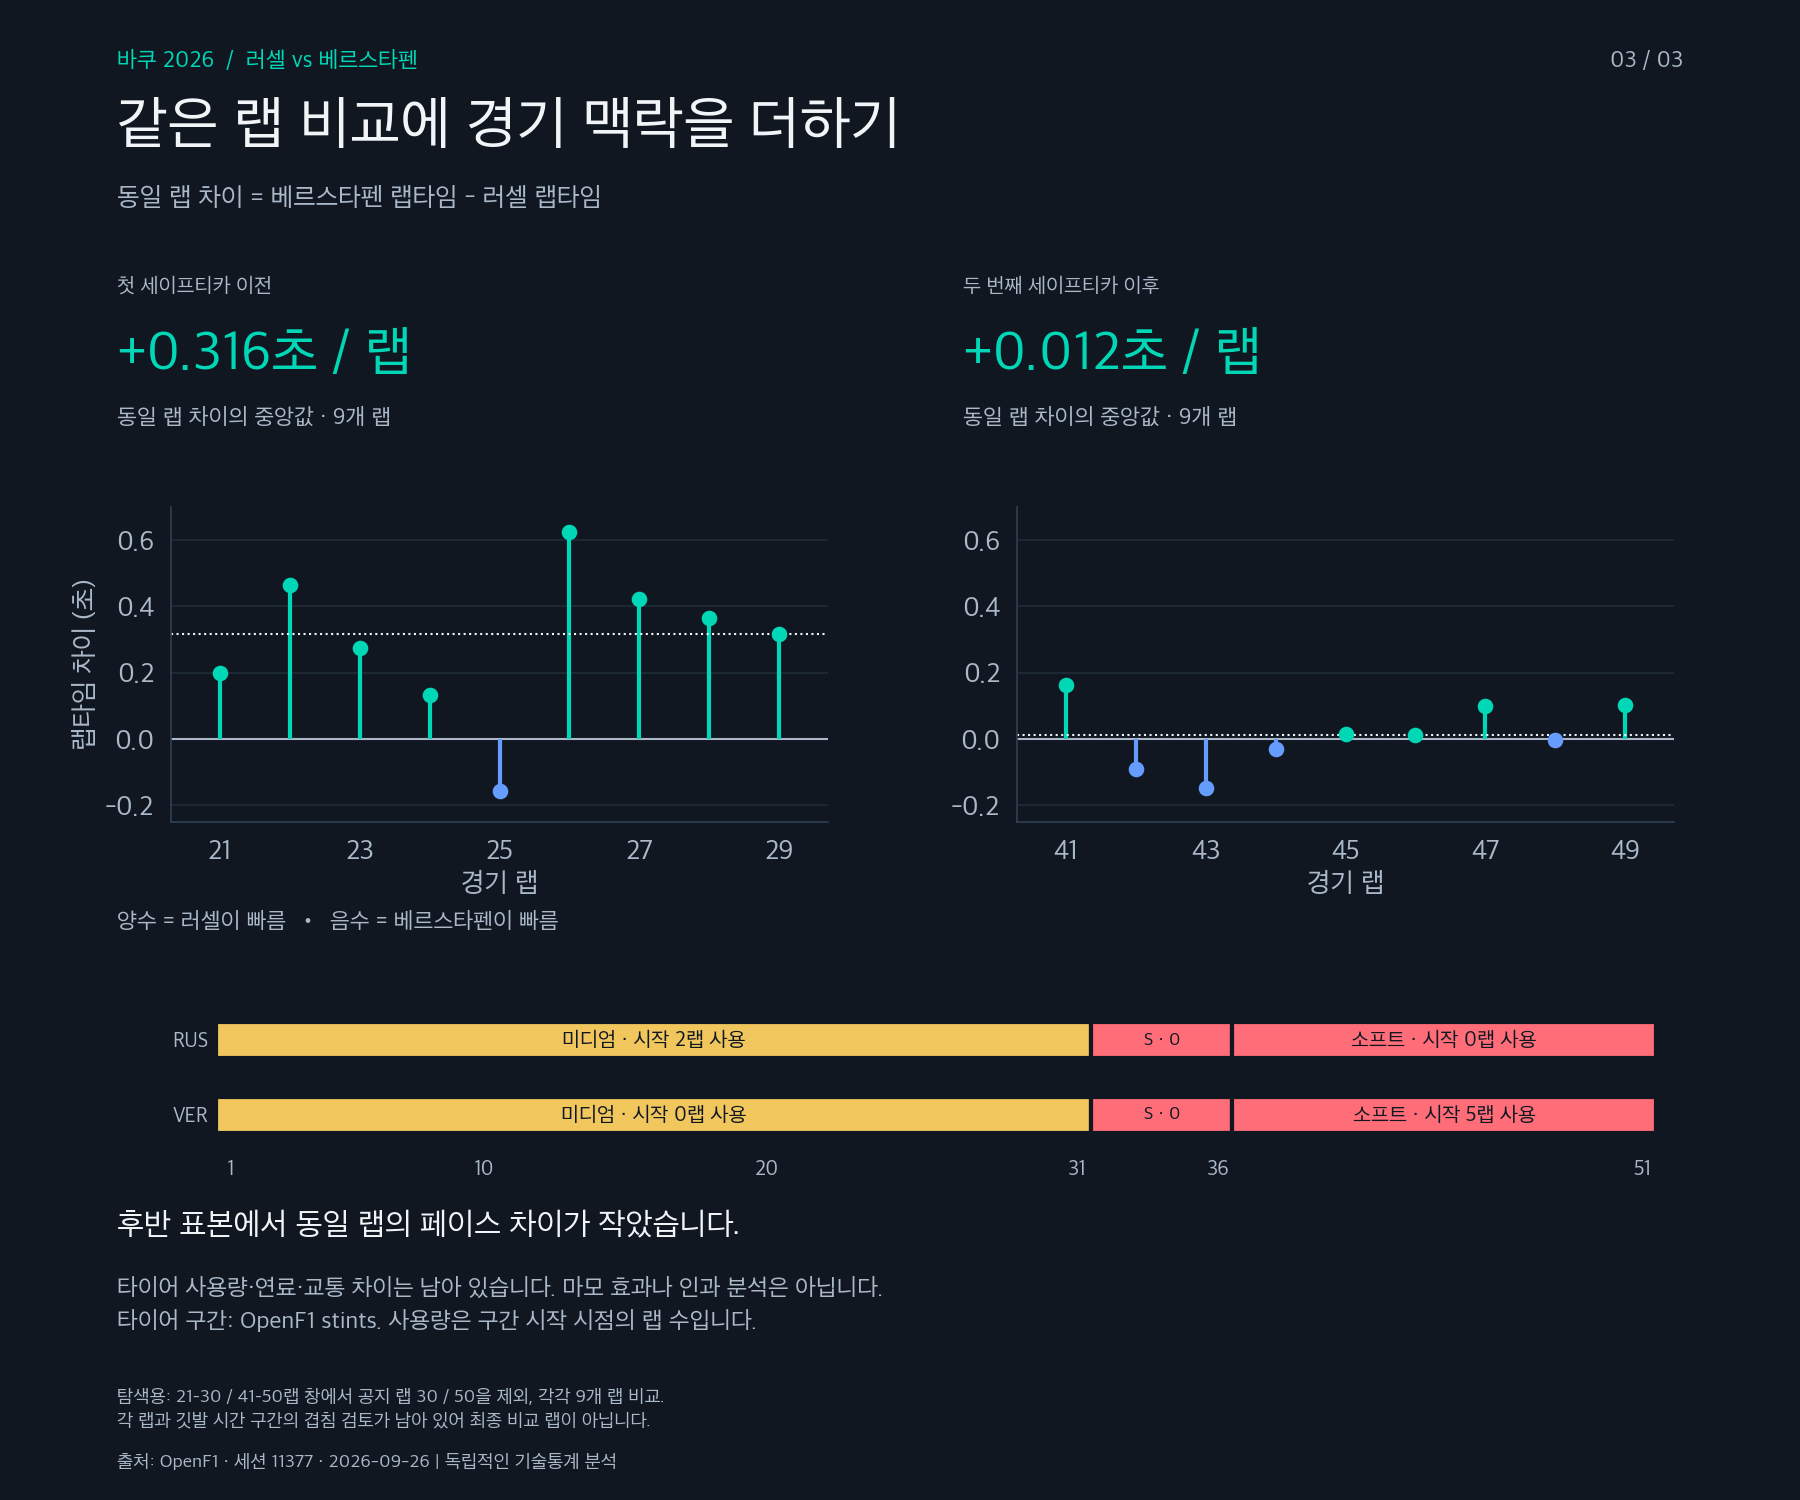

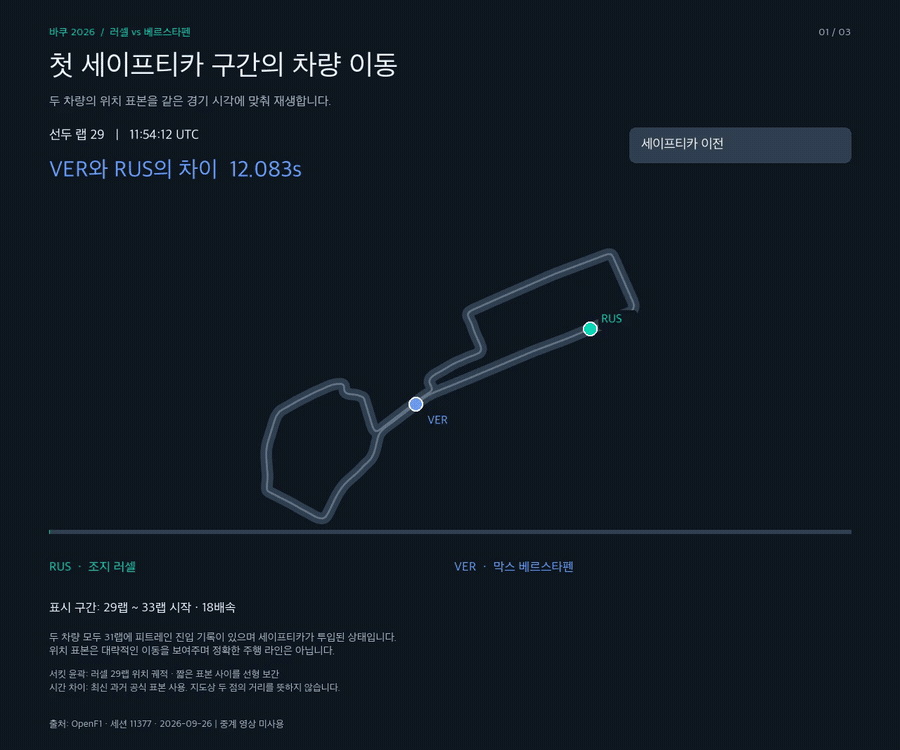

In [7]:
from IPython.display import Image, display
display(Image(filename=str(OUT / '02_gap_timeline.png')))
display(Image(filename=str(OUT / '03_paired_pace_and_tyres.png')))
display(Image(filename=str(OUT / '01_track_replay.gif')))